In [1]:
'''
Notebook for developing one-to-one sensitivity analysis figure
'''

__author__ =  'Christian Dewey'
__date__   =  '29 December 2025'
__version__ = '0.1.0'

import os
import sys
from pathlib import Path

from h5py import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pflotranutils.h5_output.calc.cross_section import CrossSection 

# Add shared module to path
sys.path.insert(0, str(Path.cwd().parent))
#sys.path.insert(0, str(Path(__file__).parent / 'shared'))
from processing.pflotran import PflotranProcessor, Region

# Add results directory to path
sys.path.insert(0, str(Path.cwd().parent.parent / 'results'))

# Add model-output directory to path
sys.path.insert(0, str(Path.cwd().parent.parent / 'model-output'))

# Add observation data directory to path
OBS_PATH = str(Path.cwd().parent.parent / 'data/observational')


#### Initialize PFLOTRAN results processor

In [8]:
processor_mzt18 = PflotranProcessor(h5_path='mzt18/2026-01-09/2026-01-09_20-31-17/pflotran-mzt18_2026-01-09_20-31-17.h5', 
                         meander='MZ',
                         perpendicular_axis='x')

processor_mzt18_spin = PflotranProcessor(h5_path='mzt18/2026-01-09/2026-01-09_20-31-17/pflotran-mzt18_2026-01-09_20-31-17_spin.h5', 
                         meander='MZ',
                         perpendicular_axis='x')


## Key methods

| Method                                         | Description                      |
|------------------------------------------------|----------------------------------|
| processor.times                                | Array of available time steps    |
| processor.component_list                       | List of available components     |
| processor.get_cells(perp_loc)                  | Set up cross-section at location |
| processor.get_snapshot_all_cells(comp, t)      | Get all cells at time t          |
| processor.get_history_at_m_coords(comp, (x,z)) | Time series at meter coords      |
| processor.plot_at_time(t, comp, ...)           | Plot cross-section               |
| processor.extract_transect_at_time(comp, t)    | Extract 1D transect data         |


In [ ]:
from processing.pflotran import PflotranProcessor

# Initialize with relative path (auto-searches in pflotran/simulations/, etc.)
processor_mzt19 = PflotranProcessor(
    h5_path='mzt19/2025-12-29/2025-12-29_12-47-14/pflotran-mzt19_2025-12-29_12-47-14.h5',
    meander='MZ',
    perpendicular_axis='x'
)


In [ ]:

# --- Explore available data ---
# List available times
print("Available times:", processor.times[:5], "...")

# List available components
print("\nAvailable components:")
processor.print_components(include='Free')  # Filter to show only 'Free' species

# --- Extract data ---
# Get cross-section cells
processor.get_cells(perp_loc=0, print_ds=True)

# Get snapshot of a component at a specific time
time_t = processor.times[10]  # Pick a time

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot cross-section at a time
processor.plot_at_time(
    time_t=time_t,
    component='Free_Fe++ [M]',
    show_inactive=False,
    show_unsat=False,
    ax=axes[0],
    unit='uM'
)

# Plot time series
axes[1].plot(fe2_history[:, 0], fe2_history[:, 1] * 1e6)
axes[1].set_xlabel('Time (h)')
axes[1].set_ylabel('Fe++ (μM)')
axes[1].set_title('Fe++ at 40m, 1m depth')

plt.tight_layout()
plt.show()


In [3]:
chem_obs_mzt19 = pd.read_csv(OBS_PATH + "/porewater/mz_2019_porewater.csv", parse_dates=['Date'])
chem_obs_mzt18 = pd.read_csv(OBS_PATH + "/porewater/mz_2018_porewater.csv", parse_dates=['Date'])


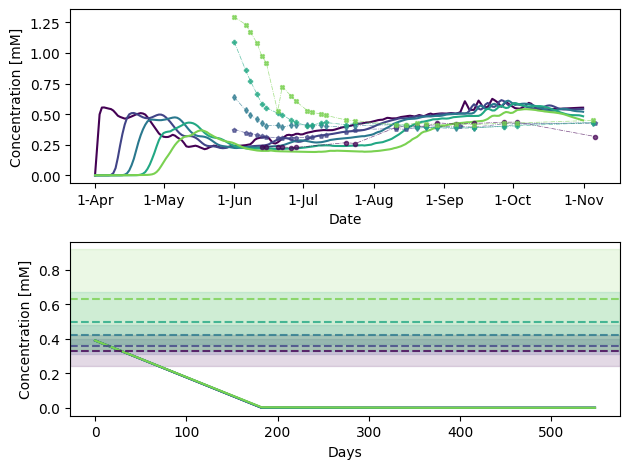

In [10]:
fig, axs = plt.subplots(2,1)
startdate = np.datetime64('2018-04-01')
processor_mzt18.plot_component_histories(component_name='Total_SO4-- [M]', startdate=startdate, ax=axs[0], unit='mM', chem_obs=chem_obs_mzt18)
processor_mzt18_spin.plot_component_histories(component_name='Total_SO4-- [M]', startdate=None, ax=axs[1], unit='mM', chem_obs=chem_obs_mzt18)
fig.tight_layout()

In [ ]:
processor_mc = PflotranProcessor(
    h5_path='mcp19/2025-12-29/2025-12-29_22-04-33/pflotran-mcp19_2025-12-29_22-04-33.h5',
    meander='MC',
    perpendicular_axis='x'
)

startdate = np.datetime64('2019-04-21')

chem_obs_mcp19 = pd.read_csv(OBS_PATH + "/porewater/mc_2019_porewater.csv", parse_dates=['Date'])


In [ ]:
fig, axs = plt.subplots(2,1, figsize = (4,8))
startdate = np.datetime64('2019-04-21')
processor_mc.plot_component_histories(component_name='Total_HCO3- [M]', startdate=startdate, ax=axs[0], unit='mM', chem_obs=chem_obs_mcp19)
processor_mc.plot_component_histories(component_name='Total_Fe++ [M]', startdate=startdate, ax=axs[1], unit='mM', chem_obs=chem_obs_mcp19)

fig.tight_layout()

In [ ]:
fig, axs = plt.subplots(2,2,figsize=(6.5, 6.5))

ax = axs[0,0]
ax = processor.plot_validation(
    'Total_HCO3- [M]',
    startdate=np.datetime64('2019-05-01'),
    chem_obs=chem_obs_mzt19,
    unit = 'mM',
    ax=ax, 
    show_legend=False
)
ax.set_title('')

ax = axs[1,0]
ax = processor_mc.plot_validation(
    'Total_HCO3- [M]',
    startdate=np.datetime64('2019-05-01'),
    chem_obs=chem_obs_mcp19,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('')

ax = axs[0,1]
ax = processor.plot_validation(
    'pH',
    startdate=np.datetime64('2019-05-01'),
    chem_obs=chem_obs_mzt19,
    ax=ax,
    show_legend=False
)
ax.set_title('')

ax = axs[1,1]
ax = processor_mc.plot_validation(
    'Total_Fe++ [M]',
    startdate=np.datetime64('2019-05-01'),
    chem_obs=chem_obs_mcp19,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('')


sns.despine()